# NTRO 26142: Sentinel-2 4x Super-Resolution (10 m to 2.5 m) with SwinIR + Monte Carlo Dropout

**Before you start:** Runtime > Change runtime type > **T4 GPU**. Then run every cell from top to bottom.
If Colab disconnects during training, reconnect and re-run cells 1-8; training resumes from `latest.pth`.

> **v2 (fixed normalization).** Run every cell from top to bottom.
> `SMOKE_TEST = True` in the training cell does a quick 3-epoch test of the whole pipeline.
> When that finishes cleanly, set `SMOKE_TEST = False` and run the training cell and the cells after it again for the real 80-epoch run.
> Cells stop with a message if a check fails (GATE A: data scale, GATE B: bicubic PSNR).


## 1. Setup
Mounts Drive, checks the GPU, sets seeds, and holds the main settings you may want to change.

In [ ]:
import os, sys, re, glob, json, math, time, random, shutil, zipfile, subprocess, warnings
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from google.colab import drive
warnings.filterwarnings('ignore')

# ---------------- settings you may change ----------------
DRIVE_DIR     = '/content/drive/MyDrive/SRM_Hackathon/full_dataset_batches'   # folder with the 29 zips
CKPT_DIR      = '/content/drive/MyDrive/ntro_sr_outputs'        # checkpoints, plots, final .pth go here
WORK_DIR      = '/content/data'                                 # local disk (fast) for unzipped data
ZIP_IDS       = [1, 2, 3, 4, 5, 6, 7]                           # zips to use
TEST_ZIP      = 7                                               # this zip = test set only
VAL_FRAC      = 0.10                                            # fraction of ROIs (from zips 1-6) for validation
SEED          = 42
BAND_NAMES    = None      # optional, e.g. ['B2','B3','B4','B8'] (only used for labels)
DISPLAY_BANDS = None      # optional RGB band indices for images, e.g. [2,1,0]; None = auto guess
LR_CROP       = None      # None = full 64x64 patches. Use 32 (multiple of 8) if you run out of memory
BATCH_SIZE    = None      # None = auto from GPU memory
NUM_WORKERS   = 2
# ----------------------------------------------------------

drive.mount('/content/drive')
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(WORK_DIR, exist_ok=True)

def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = DEVICE.type == 'cuda'
if DEVICE.type == 'cuda':
    props = torch.cuda.get_device_properties(0)
    mem_gb = props.total_memory / 1e9
    print(f'GPU: {props.name} | {mem_gb:.1f} GB')
    torch.backends.cudnn.benchmark = True
    auto_bs = 8 if mem_gb >= 14 else 6 if mem_gb >= 10 else 4 if mem_gb >= 7 else 2
else:
    print('WARNING: no GPU found. Go to Runtime > Change runtime type > T4 GPU, then restart.')
    auto_bs = 2
BATCH = BATCH_SIZE or auto_bs
print('Batch size:', BATCH, '| AMP (mixed precision):', USE_AMP)

Mounted at /content/drive
Batch size: 2 | AMP (mixed precision): False


## 2. Unzip, read manifests, check pairs, detect data format
Unzips zips 001-007 to local disk, reads each manifest, checks that every HR/LR file exists,
then detects channel count, layout, dtype and value range from the real data (nothing hardcoded).

In [ ]:
def zip_id(path, idx):
    m = re.search(r'(?<!\d)(\d{3})(?!\d)', os.path.basename(path))
    return int(m.group(1)) if m else idx + 1

all_zips = sorted(glob.glob(os.path.join(DRIVE_DIR, '*.zip')))
assert all_zips, f'No zips found in {DRIVE_DIR}. Check DRIVE_DIR.'
zip_map = {zip_id(p, i): p for i, p in enumerate(all_zips)}
print(f'{len(all_zips)} zips found in Drive.')
miss = [i for i in ZIP_IDS if i not in zip_map]
assert not miss, f'Zip ids not found: {miss}. Ids found: {sorted(zip_map)}'
for i in ZIP_IDS:
    print(f'  zip {i:03d} -> {os.path.basename(zip_map[i])}')

def extract(z):
    dest = os.path.join(WORK_DIR, os.path.splitext(os.path.basename(z))[0])
    marker = os.path.join(dest, '.done')
    if not os.path.exists(marker):
        print('Unzipping', os.path.basename(z), '...')
        os.makedirs(dest, exist_ok=True)
        with zipfile.ZipFile(z) as zf:
            zf.extractall(dest)
        open(marker, 'w').close()
    return dest

def find_manifest(root):
    c = [os.path.join(r, f) for r, _, fs in os.walk(root) for f in fs
         if 'manifest' in f.lower() and f.lower().endswith(('.csv', '.parquet', '.json'))]
    return sorted(c)[0] if c else None

def read_manifest(p):
    if p.lower().endswith('.csv'):     return pd.read_csv(p)
    if p.lower().endswith('.parquet'): return pd.read_parquet(p)
    return pd.read_json(p)

def index_npy(root):
    hr, lr = {}, {}
    for r, _, fs in os.walk(root):
        parts = r.replace('\\', '/').split('/')
        for f in fs:
            if not f.endswith('.npy'):
                continue
            if 'high_res' in parts:   hr[f] = os.path.join(r, f)
            elif 'low_res' in parts:  lr[f] = os.path.join(r, f)
    return hr, lr

def lookup(idx, name):
    b = os.path.basename(str(name))
    return idx.get(b) or idx.get(b + '.npy')

frames = []
for zid in ZIP_IDS:
    dest = extract(zip_map[zid])
    man = find_manifest(dest)
    assert man, f'No manifest found in zip {zid:03d}'
    m = read_manifest(man)
    need = {'patch_id', 'roi', 'hr_file', 'lr_file'}
    assert need <= set(m.columns), f'Manifest columns problem: {list(m.columns)}'
    hr_idx, lr_idx = index_npy(dest)
    m = m.copy()
    m['hr_path'] = m['hr_file'].map(lambda f: lookup(hr_idx, f))
    m['lr_path'] = m['lr_file'].map(lambda f: lookup(lr_idx, f))
    ok = m['hr_path'].notna() & m['lr_path'].notna()
    print(f'zip {zid:03d}: {len(m)} manifest rows | {int(ok.sum())} pairs found | '
          f'{int((~ok).sum())} missing | {m["roi"].nunique()} ROIs')
    m = m[ok].copy()
    m['zip_id'] = zid
    frames.append(m)
all_df = pd.concat(frames, ignore_index=True)
print('Total valid pairs:', len(all_df))

# ---- detect format from real data ----
sample = all_df.sample(min(60, len(all_df)), random_state=SEED)
first_lr = np.load(sample.iloc[0]['lr_path'])
first_hr = np.load(sample.iloc[0]['hr_path'])
print('\nFirst LR: shape', first_lr.shape, 'dtype', first_lr.dtype)
print('First HR: shape', first_hr.shape, 'dtype', first_hr.dtype)
if first_lr.ndim == 2:
    LAYOUT = 'HW'
elif first_lr.shape[0] < first_lr.shape[-1]:
    LAYOUT = 'CHW'
else:
    LAYOUT = 'HWC'

HR_ORDER = None   # set by the band-order check cell that follows

def to_chw(a, is_hr=False):
    a = np.asarray(a)
    if a.ndim == 2:            a = a[None]
    elif LAYOUT == 'HWC':      a = a.transpose(2, 0, 1)
    if is_hr and HR_ORDER is not None:
        a = a[HR_ORDER]
    return a

NUM_CH = to_chw(first_lr).shape[0]
LR_SIZE = to_chw(first_lr).shape[-1]
HR_SIZE = to_chw(first_hr).shape[-1]
SCALE = HR_SIZE // LR_SIZE
print(f'Detected: layout={LAYOUT}, channels={NUM_CH}, LR={LR_SIZE}px, HR={HR_SIZE}px, scale={SCALE}x')
assert SCALE == 4 and HR_SIZE == LR_SIZE * 4, 'Expected 4x pairs (e.g. 64 -> 256). Check your data.'
assert to_chw(first_hr).shape[0] == NUM_CH, 'LR and HR have different channel counts!'

dtypes, nan_cnt = set(), 0
lr_min = np.full(NUM_CH, np.inf); lr_max = np.full(NUM_CH, -np.inf); lr_sum = np.zeros(NUM_CH); cnt = 0
hr_min = np.full(NUM_CH, np.inf); hr_max = np.full(NUM_CH, -np.inf); hr_sum = np.zeros(NUM_CH)
for _, r in sample.iterrows():
    a, b = np.load(r['lr_path']), np.load(r['hr_path'])
    dtypes.add(str(a.dtype)); dtypes.add(str(b.dtype))
    a, b = to_chw(a).astype(np.float64), to_chw(b).astype(np.float64)
    nan_cnt += int((~np.isfinite(a)).sum() + (~np.isfinite(b)).sum())
    a, b = np.nan_to_num(a), np.nan_to_num(b)
    lr_min = np.minimum(lr_min, a.min((1, 2))); lr_max = np.maximum(lr_max, a.max((1, 2))); lr_sum += a.mean((1, 2))
    hr_min = np.minimum(hr_min, b.min((1, 2))); hr_max = np.maximum(hr_max, b.max((1, 2))); hr_sum += b.mean((1, 2))
    cnt += 1
print(f'\nStats from {cnt} random pairs | dtypes: {dtypes} | NaN/Inf values: {nan_cnt}')
print(f'{"band":>6} | {"LR min":>10} {"LR max":>10} {"LR mean":>10} | {"HR min":>10} {"HR max":>10} {"HR mean":>10}')
for c in range(NUM_CH):
    print(f'{c:>6} | {lr_min[c]:10.2f} {lr_max[c]:10.2f} {lr_sum[c]/cnt:10.2f} | '
          f'{hr_min[c]:10.2f} {hr_max[c]:10.2f} {hr_sum[c]/cnt:10.2f}')
gmax = max(lr_max.max(), hr_max.max())
hint = '0-1 reflectance' if gmax <= 1.5 else '0-10000 (scaled reflectance / DN)' if gmax <= 20000 else 'large range'
print('Value-range hint:', hint, '| Band order is NOT assumed. NIR is usually the band with the highest mean over vegetation.')
BAND_LABELS = BAND_NAMES if (BAND_NAMES and len(BAND_NAMES) == NUM_CH) else [f'band{i}' for i in range(NUM_CH)]

29 zips found in Drive.
  zip 001 -> paired_batch_001.zip
  zip 002 -> paired_batch_002.zip
  zip 003 -> paired_batch_003.zip
  zip 004 -> paired_batch_004.zip
  zip 005 -> paired_batch_005.zip
  zip 006 -> paired_batch_006.zip
  zip 007 -> paired_batch_007.zip
Unzipping paired_batch_001.zip ...
zip 001: 400 manifest rows | 400 pairs found | 0 missing | 100 ROIs
Unzipping paired_batch_002.zip ...
zip 002: 400 manifest rows | 400 pairs found | 0 missing | 100 ROIs
Unzipping paired_batch_003.zip ...
zip 003: 400 manifest rows | 400 pairs found | 0 missing | 100 ROIs
Unzipping paired_batch_004.zip ...
zip 004: 400 manifest rows | 400 pairs found | 0 missing | 100 ROIs
Unzipping paired_batch_005.zip ...
zip 005: 400 manifest rows | 400 pairs found | 0 missing | 100 ROIs
Unzipping paired_batch_006.zip ...
zip 006: 400 manifest rows | 400 pairs found | 0 missing | 100 ROIs
Unzipping paired_batch_007.zip ...
zip 007: 400 manifest rows | 400 pairs found | 0 missing | 100 ROIs
Total valid pairs

In [ ]:
import itertools
rows = all_df.sample(200, random_state=1)
Cm = np.zeros((NUM_CH, NUM_CH)); lr_m, hr_m = [], []; n = 0
for _, r in rows.iterrows():
    lr = to_chw(np.load(r.lr_path)).astype(np.float32)
    hr = to_chw(np.load(r.hr_path)).astype(np.float32)
    hr_d = hr.reshape(NUM_CH, LR_SIZE, SCALE, LR_SIZE, SCALE).mean((2, 4))   # HR shrunk to LR size
    lr_m.append(lr.mean((1, 2))); hr_m.append(hr.mean((1, 2)))
    for i in range(NUM_CH):
        for j in range(NUM_CH):
            a, b = lr[i].ravel(), hr_d[j].ravel()
            if a.std() > 0 and b.std() > 0:
                Cm[i, j] += np.corrcoef(a, b)[0, 1]
    n += 1
Cm /= n
print('Correlation, LR band (rows) vs HR band (cols):')
print(pd.DataFrame(Cm.round(2), index=[f'LR{i}' for i in range(NUM_CH)], columns=[f'HR{j}' for j in range(NUM_CH)]))
best = max(itertools.permutations(range(NUM_CH)), key=lambda p: sum(Cm[i, p[i]] for i in range(NUM_CH)))
gain = sum(Cm[i, best[i]] for i in range(NUM_CH)) - sum(Cm[i, i] for i in range(NUM_CH))
print('Best HR channel order:', best, '| gain over identity:', round(gain, 3))
if list(best) != list(range(NUM_CH)) and gain > 0.15:
    HR_ORDER = list(best)
    print('>>> HR bands will be REORDERED to match LR:', HR_ORDER)
else:
    HR_ORDER = None
    print('>>> Band order already matches. No reordering.')


Correlation, LR band (rows) vs HR band (cols):
      HR0   HR1   HR2   HR3
LR0  0.86  0.82  0.82  0.33
LR1  0.82  0.86  0.83  0.39
LR2  0.80  0.82  0.86  0.28
LR3  0.31  0.39  0.27  0.82
Best HR channel order: (0, 1, 2, 3) | gain over identity: 0.0
>>> Band order already matches. No reordering.


## 3. ROI-level train / val / test lists
Split by ROI (never by patch). Zip 007 = test. From zips 001-006, 10% of ROIs (seeded) = validation.

In [ ]:
def rng_str(vals):
    v = sorted(vals)
    return f'{v[0]} .. {v[-1]}' if v else 'n/a'

print('ROIs per zip (from the roi column):')
for zid in ZIP_IDS:
    r = all_df.loc[all_df.zip_id == zid, 'roi'].unique().tolist()
    print(f'  zip {zid:03d}: {len(r)} ROIs, range {rng_str(r)}')

test_df_all = all_df[all_df.zip_id == TEST_ZIP]
tv_df_all = all_df[all_df.zip_id != TEST_ZIP]
test_rois = sorted(test_df_all['roi'].unique().tolist())
tv_rois = sorted(tv_df_all['roi'].unique().tolist())

leak = set(test_rois) & set(tv_rois)
if leak:
    print(f'WARNING: {len(leak)} ROIs appear in both test and train zips. Removing them from train/val to avoid leakage.')
    tv_rois = [r for r in tv_rois if r not in leak]

rs = np.random.RandomState(SEED)
perm = rs.permutation(len(tv_rois))
n_val = max(1, int(round(VAL_FRAC * len(tv_rois))))
val_rois = sorted(tv_rois[i] for i in perm[:n_val])
train_rois = sorted(tv_rois[i] for i in perm[n_val:])

assert not (set(train_rois) & set(val_rois)), 'train/val ROI overlap!'
assert not (set(train_rois) & set(test_rois)), 'train/test ROI overlap!'
assert not (set(val_rois) & set(test_rois)), 'val/test ROI overlap!'

train_df = tv_df_all[tv_df_all['roi'].isin(train_rois)].reset_index(drop=True)
val_df = tv_df_all[tv_df_all['roi'].isin(val_rois)].reset_index(drop=True)
test_df = test_df_all[test_df_all['roi'].isin(test_rois)].reset_index(drop=True)

print(f'\nTRAIN: {len(train_rois)} ROIs, {len(train_df)} patches, ROI range {rng_str(train_rois)}')
print(f'VAL  : {len(val_rois)} ROIs, {len(val_df)} patches, ROI range {rng_str(val_rois)}')
print(f'TEST : {len(test_rois)} ROIs, {len(test_df)} patches, ROI range {rng_str(test_rois)} (zip {TEST_ZIP:03d}, untouched in training)')
if len(test_rois) != 100:
    print('Note: test zip has', len(test_rois), 'ROIs (expected 100).')
with open(os.path.join(CKPT_DIR, 'splits.json'), 'w') as f:
    json.dump(dict(train_rois=train_rois, val_rois=val_rois, test_rois=test_rois, seed=SEED), f, default=str, indent=1)
print('Saved splits.json to', CKPT_DIR)

ROIs per zip (from the roi column):
  zip 001: 100 ROIs, range ROI_0000 .. ROI_0099
  zip 002: 100 ROIs, range ROI_0100 .. ROI_0199
  zip 003: 100 ROIs, range ROI_0200 .. ROI_0299
  zip 004: 100 ROIs, range ROI_0300 .. ROI_0399
  zip 005: 100 ROIs, range ROI_0400 .. ROI_0499
  zip 006: 100 ROIs, range ROI_0500 .. ROI_0599
  zip 007: 100 ROIs, range ROI_0600 .. ROI_0699

TRAIN: 540 ROIs, 2160 patches, ROI range ROI_0000 .. ROI_0599
VAL  : 60 ROIs, 240 patches, ROI range ROI_0002 .. ROI_0596
TEST : 100 ROIs, 400 patches, ROI range ROI_0600 .. ROI_0699 (zip 007, untouched in training)
Saved splits.json to /content/drive/MyDrive/ntro_sr_outputs


## 4. Dataset / DataLoader
Normalization is computed from TRAIN data only (per-band robust min-max: p0.5 -> 0, p99.5 -> 1, no clipping).
Training uses paired random flips and 90-degree rotations (same transform for LR and HR).

In [ ]:
# ---- normalization stats from train patches only: LR and HR get their OWN stats ----
tr_sample = train_df.sample(min(200, len(train_df)), random_state=SEED)

def robust_stats(col, is_hr):
    pix = [[] for _ in range(NUM_CH)]
    vmin = np.full(NUM_CH, np.inf); vmax = np.full(NUM_CH, -np.inf)
    for p in tr_sample[col]:
        a = np.nan_to_num(to_chw(np.load(p), is_hr).astype(np.float32))
        for c in range(NUM_CH):
            pix[c].append(a[c].ravel()[::7])
            vmin[c] = min(vmin[c], a[c].min()); vmax[c] = max(vmax[c], a[c].max())
    lo = np.array([np.percentile(np.concatenate(pix[c]), 0.5)  for c in range(NUM_CH)], dtype=np.float32)
    hi = np.array([np.percentile(np.concatenate(pix[c]), 99.5) for c in range(NUM_CH)], dtype=np.float32)
    hi = np.where(hi - lo < 1e-6, lo + 1.0, hi).astype(np.float32)
    return lo, hi, vmin, vmax

LO_LR, HI_LR, vmin_lr, vmax_lr = robust_stats('lr_path', False)
LO_HR, HI_HR, vmin_hr, vmax_hr = robust_stats('hr_path', True)
LO, HI = LO_HR, HI_HR          # loss / SAM / metrics work in HR units
vmin, vmax = vmin_hr, vmax_hr
print('Normalization (train only)')
for c in range(NUM_CH):
    print(f'  {BAND_LABELS[c]}: LR lo={LO_LR[c]:.1f} hi={HI_LR[c]:.1f} | HR lo={LO_HR[c]:.1f} hi={HI_HR[c]:.1f}')

NORM = dict(lr_lo=LO_LR.tolist(), lr_hi=HI_LR.tolist(), hr_lo=LO_HR.tolist(), hr_hi=HI_HR.tolist(),
            vmin=vmin_hr.tolist(), vmax=vmax_hr.tolist(), hr_order=HR_ORDER,
            num_ch=int(NUM_CH), scale=int(SCALE), layout=LAYOUT, band_names=BAND_LABELS)
LO_T = torch.tensor(LO, device=DEVICE).view(1, -1, 1, 1)
RNG_T = torch.tensor(HI - LO, device=DEVICE).view(1, -1, 1, 1)

if LR_CROP is not None:
    assert LR_CROP % 8 == 0 and LR_CROP <= LR_SIZE, 'LR_CROP must be a multiple of 8 and <= patch size'

class SRPairs(Dataset):
    def __init__(self, frame, augment=False, lr_crop=None):
        self.lr_paths = frame['lr_path'].tolist()
        self.hr_paths = frame['hr_path'].tolist()
        self.augment, self.lr_crop = augment, lr_crop
        self.lo_lr, self.rng_lr = LO_LR[:, None, None], (HI_LR - LO_LR)[:, None, None]
        self.lo_hr, self.rng_hr = LO_HR[:, None, None], (HI_HR - LO_HR)[:, None, None]
    def __len__(self):
        return len(self.lr_paths)
    def __getitem__(self, i):
        lr = np.nan_to_num(to_chw(np.load(self.lr_paths[i]), False).astype(np.float32))
        hr = np.nan_to_num(to_chw(np.load(self.hr_paths[i]), True).astype(np.float32))
        lr = (lr - self.lo_lr) / self.rng_lr
        hr = (hr - self.lo_hr) / self.rng_hr
        if self.lr_crop and self.lr_crop < lr.shape[-1]:
            y = random.randint(0, lr.shape[1] - self.lr_crop); x = random.randint(0, lr.shape[2] - self.lr_crop)
            lr = lr[:, y:y + self.lr_crop, x:x + self.lr_crop]
            hr = hr[:, y * SCALE:(y + self.lr_crop) * SCALE, x * SCALE:(x + self.lr_crop) * SCALE]
        if self.augment:
            if random.random() < 0.5: lr, hr = lr[:, :, ::-1], hr[:, :, ::-1]
            if random.random() < 0.5: lr, hr = lr[:, ::-1, :], hr[:, ::-1, :]
            k = random.randint(0, 3)
            if k: lr, hr = np.rot90(lr, k, (1, 2)), np.rot90(hr, k, (1, 2))
        return torch.from_numpy(np.ascontiguousarray(lr)), torch.from_numpy(np.ascontiguousarray(hr))

def seed_worker(worker_id):
    s = (torch.initial_seed() + worker_id) % (2 ** 32)
    np.random.seed(s); random.seed(s)

g = torch.Generator(); g.manual_seed(SEED)
dl_kw = dict(num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == 'cuda'), worker_init_fn=seed_worker,
             persistent_workers=NUM_WORKERS > 0)
train_ds = SRPairs(train_df, augment=True, lr_crop=LR_CROP)
val_ds, test_ds = SRPairs(val_df), SRPairs(test_df)
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, drop_last=True, generator=g, **dl_kw)
val_loader = DataLoader(val_ds, batch_size=BATCH, shuffle=False, **dl_kw)
test_loader = DataLoader(test_ds, batch_size=BATCH, shuffle=False, **dl_kw)

lr_b, hr_b = next(iter(train_loader))
print(f'\nOne train batch: LR {tuple(lr_b.shape)}  HR {tuple(hr_b.shape)}')
print(f'Normalized LR range: {lr_b.min():.3f} .. {lr_b.max():.3f} | HR range: {hr_b.min():.3f} .. {hr_b.max():.3f}')
print(f'Batches per epoch: train {len(train_loader)}, val {len(val_loader)}, test {len(test_loader)}')
assert hr_b.max() > 0.5 and lr_b.max() < 5, 'STOP: LR/HR are still on different scales. Check the normalization above.'
print('GATE A passed: LR and HR are both on a ~0..1 scale.')


Normalization (train only)
  band0: LR lo=138.0 hi=3430.0 | HR lo=34.0 hi=197.0
  band1: LR lo=248.0 hi=2670.0 | HR lo=43.0 hi=189.0
  band2: LR lo=94.0 hi=2018.0 | HR lo=38.0 hi=172.0
  band3: LR lo=1284.0 hi=5716.0 | HR lo=55.0 hi=205.0

One train batch: LR (2, 4, 64, 64)  HR (2, 4, 256, 256)
Normalized LR range: -0.023 .. 1.373 | HR range: -0.360 .. 1.306
Batches per epoch: train 1080, val 120, test 200
GATE A passed: LR and HR are both on a ~0..1 scale.


In [ ]:
# quick look: LR and HR should both be visible and have similar colours
fig, ax = plt.subplots(3, 2, figsize=(7, 10))
for k, i in enumerate(np.random.RandomState(3).choice(len(train_ds), 3, replace=False)):
    lr, hr = train_ds[i]
    for c, (im, t) in enumerate([(lr.numpy(), 'LR'), (hr.numpy(), 'HR')]):
        ax[k, c].imshow(np.clip(im[[2, 1, 0]].transpose(1, 2, 0), 0, 1)); ax[k, c].set_title(t); ax[k, c].axis('off')
plt.tight_layout(); plt.show()


## 5. Baselines: bicubic metrics + a small SRCNN
Defines the metrics used everywhere (PSNR, SSIM, SAM, per-band PSNR). PSNR/SSIM are in normalized units
(range 1.0). SAM is computed on the original physical values (angle between spectra, in degrees; lower is better).

In [ ]:
def psnr_batch(sr, hr):
    mse = ((sr - hr) ** 2).flatten(1).mean(1).clamp_min(1e-12)
    return 10 * torch.log10(1.0 / mse)

def _gauss_win(ws=11, sigma=1.5):
    ax = torch.arange(ws, dtype=torch.float32) - ws // 2
    g = torch.exp(-ax ** 2 / (2 * sigma ** 2)); g = g / g.sum()
    return (g[:, None] * g[None, :])[None, None]

def ssim_batch(x, y):
    C = x.shape[1]
    w = _gauss_win().to(x.device, x.dtype).expand(C, 1, 11, 11).contiguous()
    c1, c2 = 0.01 ** 2, 0.03 ** 2
    mx, my = F.conv2d(x, w, groups=C), F.conv2d(y, w, groups=C)
    sxx = F.conv2d(x * x, w, groups=C) - mx ** 2
    syy = F.conv2d(y * y, w, groups=C) - my ** 2
    sxy = F.conv2d(x * y, w, groups=C) - mx * my
    m = ((2 * mx * my + c1) * (2 * sxy + c2)) / ((mx ** 2 + my ** 2 + c1) * (sxx + syy + c2))
    return m.flatten(1).mean(1)

def sam_deg(sr, hr):
    if sr.shape[1] < 2:
        return torch.full((sr.shape[0],), float('nan'), device=sr.device)
    p, t = sr * RNG_T + LO_T, hr * RNG_T + LO_T
    cos = ((p * t).sum(1) / (p.norm(dim=1) * t.norm(dim=1) + 1e-8)).clamp(-1, 1)
    return torch.rad2deg(torch.acos(cos)).flatten(1).mean(1)

@torch.no_grad()
def evaluate(predict, loader, max_batches=None):
    P, S, A, B = [], [], [], []
    for i, (lr, hr) in enumerate(loader):
        if max_batches and i >= max_batches:
            break
        lr, hr = lr.to(DEVICE, non_blocking=True), hr.to(DEVICE, non_blocking=True)
        sr = predict(lr).float()
        P.append(psnr_batch(sr, hr).cpu()); S.append(ssim_batch(sr, hr).cpu()); A.append(sam_deg(sr, hr).cpu())
        mse_b = ((sr - hr) ** 2).mean((2, 3)).clamp_min(1e-12)
        B.append((10 * torch.log10(1.0 / mse_b)).cpu())
    P, S, A, B = torch.cat(P), torch.cat(S), torch.cat(A), torch.cat(B)
    return dict(psnr=P.mean().item(), ssim=S.mean().item(), sam=float(np.nanmean(A.numpy())),
                band_psnr=B.mean(0).tolist())

bicubic_fn = lambda x: F.interpolate(x, scale_factor=SCALE, mode='bicubic', align_corners=False)

class SRCNN(nn.Module):   # small residual SRCNN (9-1-5) applied after bicubic upsampling
    def __init__(self, c):
        super().__init__()
        self.net = nn.Sequential(nn.Conv2d(c, 64, 9, padding=4), nn.ReLU(True),
                                 nn.Conv2d(64, 32, 1), nn.ReLU(True),
                                 nn.Conv2d(32, c, 5, padding=2))
    def forward(self, x):
        up = F.interpolate(x, scale_factor=SCALE, mode='bicubic', align_corners=False)
        return up + self.net(up)

SRCNN_EPOCHS, RETRAIN_SRCNN = 5, False
SRCNN_PATH = os.path.join(CKPT_DIR, 'srcnn_v2.pth')   # v2 = trained with fixed normalization
srcnn = SRCNN(NUM_CH).to(DEVICE)
if os.path.exists(SRCNN_PATH) and not RETRAIN_SRCNN:
    srcnn.load_state_dict(torch.load(SRCNN_PATH, map_location=DEVICE))
    print('Loaded saved SRCNN.')
else:
    opt_s = torch.optim.Adam(srcnn.parameters(), 1e-3)
    scaler_s = torch.cuda.amp.GradScaler(enabled=USE_AMP)
    for ep in range(SRCNN_EPOCHS):
        srcnn.train(); tot, n = 0.0, 0
        for lr, hr in train_loader:
            lr, hr = lr.to(DEVICE), hr.to(DEVICE)
            with torch.autocast('cuda', dtype=torch.float16, enabled=USE_AMP):
                sr = srcnn(lr)
            loss = F.l1_loss(sr.float(), hr)
            opt_s.zero_grad(set_to_none=True)
            scaler_s.scale(loss).backward(); scaler_s.step(opt_s); scaler_s.update()
            tot += loss.item() * lr.size(0); n += lr.size(0)
        print(f'SRCNN epoch {ep + 1}/{SRCNN_EPOCHS}  L1 {tot / n:.5f}')
    torch.save(srcnn.state_dict(), SRCNN_PATH)
srcnn.eval()

def srcnn_fn(x):
    with torch.autocast('cuda', dtype=torch.float16, enabled=USE_AMP):
        return srcnn(x)

BASE_VAL = {'Bicubic': evaluate(bicubic_fn, val_loader), 'SRCNN': evaluate(srcnn_fn, val_loader)}
print('\nValidation baselines (PSNR dB / SSIM higher is better, SAM degrees lower is better)')
print(pd.DataFrame({k: {m: v[m] for m in ('psnr', 'ssim', 'sam')} for k, v in BASE_VAL.items()}).T.round(4))
print('SwinIR must beat these numbers.')
assert BASE_VAL['Bicubic']['psnr'] > 12, 'STOP: bicubic PSNR is far too low, LR/HR scale mismatch still present.'
print('GATE B passed: bicubic PSNR is sensible.')

SRCNN epoch 1/5  L1 0.12561
SRCNN epoch 2/5  L1 0.12027
SRCNN epoch 3/5  L1 0.12067
SRCNN epoch 4/5  L1 0.11959
SRCNN epoch 5/5  L1 0.11949

Validation baselines (PSNR dB / SSIM higher is better, SAM degrees lower is better)
            psnr    ssim     sam
Bicubic  12.5703  0.3666  7.6346
SRCNN    16.6965  0.4375  5.7417
SwinIR must beat these numbers.
GATE B passed: bicubic PSNR is sensible.


## 6. SwinIR 4x with detected channels and switchable dropout
Own compact SwinIR (no extra packages). It predicts a residual on top of the bicubic image, so the output
starts as bicubic and cannot drift far in spectral values. Dropout sits in attention and MLP layers.
The model code is kept in a string (MODEL_SRC) so the same code is written into the standalone inference script.

In [ ]:
MODEL_SRC = r"""
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class Mlp(nn.Module):
    def __init__(self, dim, hidden, drop):
        super().__init__()
        self.fc1 = nn.Linear(dim, hidden)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden, dim)
        self.drop = nn.Dropout(drop)
    def forward(self, x):
        return self.drop(self.fc2(self.drop(self.act(self.fc1(x)))))

def window_partition(x, ws):
    B, H, W, C = x.shape
    x = x.view(B, H // ws, ws, W // ws, ws, C)
    return x.permute(0, 1, 3, 2, 4, 5).reshape(-1, ws, ws, C)

def window_reverse(w, ws, H, W):
    B = int(w.shape[0] / (H * W / ws / ws))
    x = w.view(B, H // ws, W // ws, ws, ws, -1)
    return x.permute(0, 1, 3, 2, 4, 5).reshape(B, H, W, -1)

class WindowAttention(nn.Module):
    def __init__(self, dim, ws, heads, drop):
        super().__init__()
        self.ws, self.heads = ws, heads
        self.scale = (dim // heads) ** -0.5
        self.rpb_table = nn.Parameter(torch.zeros((2 * ws - 1) * (2 * ws - 1), heads))
        nn.init.trunc_normal_(self.rpb_table, std=0.02)
        coords = torch.stack(torch.meshgrid(torch.arange(ws), torch.arange(ws), indexing='ij')).flatten(1)
        rel = (coords[:, :, None] - coords[:, None, :]).permute(1, 2, 0).contiguous()
        rel[:, :, 0] += ws - 1
        rel[:, :, 1] += ws - 1
        rel[:, :, 0] *= 2 * ws - 1
        self.register_buffer('rel_index', rel.sum(-1))
        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)
        self.attn_drop = nn.Dropout(drop)
        self.proj_drop = nn.Dropout(drop)
    def forward(self, x, mask=None):
        Bn, N, C = x.shape
        qkv = self.qkv(x).reshape(Bn, N, 3, self.heads, C // self.heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q * self.scale) @ k.transpose(-2, -1)
        bias = self.rpb_table[self.rel_index.view(-1)].view(N, N, -1).permute(2, 0, 1)
        attn = attn + bias.unsqueeze(0)
        if mask is not None:
            nW = mask.shape[0]
            attn = attn.view(Bn // nW, nW, self.heads, N, N) + mask.unsqueeze(1).unsqueeze(0)
            attn = attn.view(-1, self.heads, N, N)
        attn = self.attn_drop(attn.softmax(-1))
        x = (attn @ v).transpose(1, 2).reshape(Bn, N, C)
        return self.proj_drop(self.proj(x))

class SwinBlock(nn.Module):
    def __init__(self, dim, heads, ws, shift, mlp_ratio, drop):
        super().__init__()
        self.ws, self.shift = ws, shift
        self.norm1 = nn.LayerNorm(dim)
        self.attn = WindowAttention(dim, ws, heads, drop)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = Mlp(dim, int(dim * mlp_ratio), drop)
        self._masks = {}
    def get_mask(self, H, W, device):
        key = (H, W, str(device))
        if key not in self._masks:
            img = torch.zeros(1, H, W, 1, device=device)
            cnt = 0
            sl = (slice(0, -self.ws), slice(-self.ws, -self.shift), slice(-self.shift, None))
            for h in sl:
                for w in sl:
                    img[:, h, w, :] = cnt
                    cnt += 1
            mw = window_partition(img, self.ws).view(-1, self.ws * self.ws)
            m = mw.unsqueeze(1) - mw.unsqueeze(2)
            self._masks[key] = m.masked_fill(m != 0, -100.0).masked_fill(m == 0, 0.0)
        return self._masks[key]
    def forward(self, x, H, W):
        B, L, C = x.shape
        shortcut = x
        x = self.norm1(x).view(B, H, W, C)
        use_shift = self.shift > 0 and min(H, W) > self.ws
        if use_shift:
            x = torch.roll(x, (-self.shift, -self.shift), (1, 2))
            mask = self.get_mask(H, W, x.device)
        else:
            mask = None
        w = window_partition(x, self.ws).view(-1, self.ws * self.ws, C)
        w = self.attn(w, mask)
        x = window_reverse(w.view(-1, self.ws, self.ws, C), self.ws, H, W)
        if use_shift:
            x = torch.roll(x, (self.shift, self.shift), (1, 2))
        x = shortcut + x.reshape(B, L, C)
        return x + self.mlp(self.norm2(x))

class RSTB(nn.Module):
    def __init__(self, dim, depth, heads, ws, mlp_ratio, drop):
        super().__init__()
        self.blocks = nn.ModuleList([SwinBlock(dim, heads, ws, 0 if i % 2 == 0 else ws // 2, mlp_ratio, drop)
                                     for i in range(depth)])
        self.conv = nn.Conv2d(dim, dim, 3, 1, 1)
    def forward(self, x, H, W):
        res = x
        for b in self.blocks:
            x = b(x, H, W)
        B, L, C = x.shape
        x = x.transpose(1, 2).reshape(B, C, H, W)
        x = self.conv(x).flatten(2).transpose(1, 2)
        return res + x

class SwinIR(nn.Module):
    def __init__(self, in_ch=4, embed=96, depths=(4, 4, 4, 4), heads=(6, 6, 6, 6), ws=8,
                 mlp_ratio=2.0, drop=0.1, scale=4):
        super().__init__()
        self.ws, self.scale = ws, scale
        self.conv_first = nn.Conv2d(in_ch, embed, 3, 1, 1)
        self.layers = nn.ModuleList([RSTB(embed, d, h, ws, mlp_ratio, drop) for d, h in zip(depths, heads)])
        self.norm = nn.LayerNorm(embed)
        self.conv_after = nn.Conv2d(embed, embed, 3, 1, 1)
        self.conv_before = nn.Sequential(nn.Conv2d(embed, 64, 3, 1, 1), nn.LeakyReLU(0.2, True))
        up = []
        for _ in range(int(math.log2(scale))):
            up += [nn.Conv2d(64, 256, 3, 1, 1), nn.PixelShuffle(2)]
        self.upsample = nn.Sequential(*up)
        self.conv_last = nn.Conv2d(64, in_ch, 3, 1, 1)
        self.apply(self._init)
        nn.init.zeros_(self.conv_last.weight)
        nn.init.zeros_(self.conv_last.bias)
    def _init(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)
    def forward(self, x):
        B, C, H, W = x.shape
        ph, pw = (self.ws - H % self.ws) % self.ws, (self.ws - W % self.ws) % self.ws
        xp = F.pad(x, (0, pw, 0, ph), mode='replicate') if (ph or pw) else x
        Hp, Wp = xp.shape[2:]
        base = F.interpolate(xp, scale_factor=self.scale, mode='bicubic', align_corners=False)
        f = self.conv_first(xp)
        t = f.flatten(2).transpose(1, 2)
        for layer in self.layers:
            t = layer(t, Hp, Wp)
        t = self.norm(t).transpose(1, 2).reshape(B, -1, Hp, Wp)
        f = self.conv_after(t) + f
        out = self.conv_last(self.upsample(self.conv_before(f))) + base
        return out[:, :, :H * self.scale, :W * self.scale]

def set_dropout(model, p):
    for m in model.modules():
        if isinstance(m, nn.Dropout):
            m.p = float(p)

def enable_mc_dropout(model):
    # eval mode everywhere, but keep Dropout layers active (Monte Carlo Dropout)
    model.eval()
    for m in model.modules():
        if isinstance(m, nn.Dropout):
            m.train()
"""
exec(MODEL_SRC, globals())

# ---- model settings (change here) ----
EMBED, DEPTHS, HEADS, WINDOW = 96, (4, 4, 4, 4), (6, 6, 6, 6), 8
MLP_RATIO, DROPOUT_P = 2.0, 0.1       # DROPOUT_P > 0 is needed for MC Dropout uncertainty
MODEL_CFG = dict(in_ch=NUM_CH, embed=EMBED, depths=list(DEPTHS), heads=list(HEADS), ws=WINDOW,
                 mlp_ratio=MLP_RATIO, drop=DROPOUT_P, scale=SCALE)
model = SwinIR(**MODEL_CFG).to(DEVICE)
print(f'SwinIR built: {sum(p.numel() for p in model.parameters()) / 1e6:.2f} M parameters, {NUM_CH} channels in/out')
with torch.no_grad():
    model.eval()
    out = model(torch.randn(2, NUM_CH, LR_SIZE, LR_SIZE, device=DEVICE))
assert out.shape == (2, NUM_CH, LR_SIZE * 4, LR_SIZE * 4), out.shape
print('Shape test OK:', tuple(out.shape), '| set_dropout(model, p) changes dropout; p=0 turns it off.')

SwinIR built: 1.99 M parameters, 4 channels in/out
Shape test OK: (2, 4, 256, 256) | set_dropout(model, p) changes dropout; p=0 turns it off.


## 7. Loss: Charbonnier + SAM
Charbonnier keeps pixel values close to the truth (smooth L1). SAM keeps the spectral shape (including NIR)
correct. Change the weights below. Optional per-band weights (e.g. give NIR a higher weight).

In [ ]:
W_CHAR, W_SAM = 1.0, 0.5           # loss weights: easy to change
BAND_WEIGHTS = None                # e.g. [1, 1, 1, 2] to weight the last band (NIR) more; None = equal

class SRLoss(nn.Module):
    def __init__(self, w_char=1.0, w_sam=0.5, eps=1e-3, band_w=None):
        super().__init__()
        self.w_char, self.w_sam, self.eps = w_char, w_sam, eps
        bw = torch.ones(NUM_CH) if band_w is None else torch.tensor(band_w, dtype=torch.float32)
        assert len(bw) == NUM_CH, 'BAND_WEIGHTS length must equal number of channels'
        self.register_buffer('bw', (bw / bw.mean()).view(1, -1, 1, 1))
    def forward(self, sr, hr):
        sr, hr = sr.float(), hr.float()
        char = (torch.sqrt((sr - hr) ** 2 + self.eps ** 2) * self.bw).mean()
        if self.w_sam > 0 and sr.shape[1] > 1:
            p, t = sr * RNG_T + LO_T, hr * RNG_T + LO_T
            cos = ((p * t).sum(1) / (p.norm(dim=1) * t.norm(dim=1) + 1e-8)).clamp(-1 + 1e-4, 1 - 1e-4)
            sam = torch.acos(cos).mean()
        else:
            sam = sr.new_zeros(())
        return self.w_char * char + self.w_sam * sam, dict(char=char.item(), sam=sam.item())

criterion = SRLoss(W_CHAR, W_SAM, band_w=BAND_WEIGHTS).to(DEVICE)
l, parts = criterion(torch.rand(2, NUM_CH, 16, 16, device=DEVICE), torch.rand(2, NUM_CH, 16, 16, device=DEVICE))
print('Loss test OK:', round(l.item(), 4), parts)

Loss test OK: 0.544 {'char': 0.33554184436798096, 'sam': 0.4170107841491699}


## 8. Training
Mixed precision, validation PSNR/SSIM/SAM every epoch, "latest" and "best" checkpoints saved to Drive.
If Colab disconnects, just re-run cells 1-8: training resumes from latest.pth.

Starting fresh training.
Epoch   1/80 | loss 0.17877 | val PSNR 16.378 SSIM 0.4364 SAM 6.014 | lr 1.0e-04 | 90s  <- best
Epoch   2/80 | loss 0.17335 | val PSNR 15.454 SSIM 0.4314 SAM 5.869 | lr 2.0e-04 | 86s
Epoch   3/80 | loss 0.16709 | val PSNR 16.634 SSIM 0.4390 SAM 5.786 | lr 2.0e-04 | 86s  <- best
Epoch   4/80 | loss 0.16554 | val PSNR 16.285 SSIM 0.4399 SAM 5.645 | lr 2.0e-04 | 87s
Epoch   5/80 | loss 0.16587 | val PSNR 16.428 SSIM 0.4390 SAM 5.747 | lr 2.0e-04 | 86s
Epoch   6/80 | loss 0.16198 | val PSNR 16.613 SSIM 0.4401 SAM 5.495 | lr 2.0e-04 | 86s
Epoch   7/80 | loss 0.16205 | val PSNR 16.805 SSIM 0.4391 SAM 5.525 | lr 2.0e-04 | 86s  <- best
Epoch   8/80 | loss 0.16116 | val PSNR 16.484 SSIM 0.4395 SAM 5.652 | lr 2.0e-04 | 86s
Epoch   9/80 | loss 0.16029 | val PSNR 16.108 SSIM 0.4391 SAM 5.701 | lr 2.0e-04 | 86s
Epoch  10/80 | loss 0.16071 | val PSNR 16.785 SSIM 0.4424 SAM 5.471 | lr 2.0e-04 | 86s
Epoch  11/80 | loss 0.15880 | val PSNR 16.739 SSIM 0.4448 SAM 5.581 | lr 1.9e-

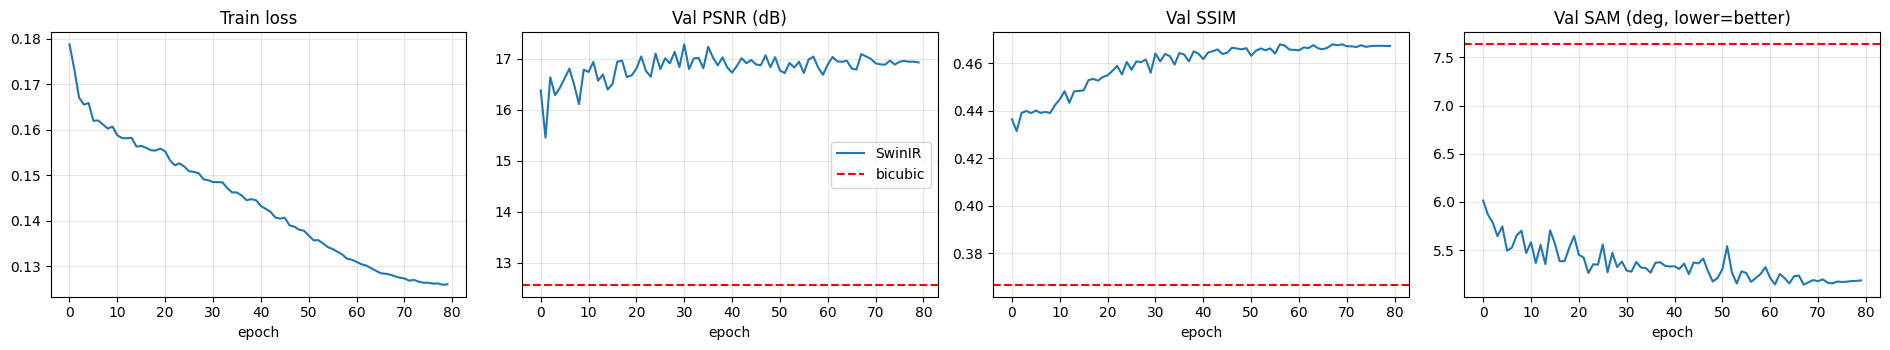

Best val PSNR: 17.280 dB | best checkpoint: /content/drive/MyDrive/ntro_sr_outputs/best_v2.pth


In [ ]:
SMOKE_TEST = False     # True = quick 3-epoch test run. After it looks fine, set to False for the real 80-epoch run.
EPOCHS, LR, WEIGHT_DECAY, GRAD_CLIP, WARMUP_EPOCHS = (3 if SMOKE_TEST else 80), 2e-4, 1e-4, 1.0, 2
RESUME = True
TIME_BUDGET_MIN = None      # e.g. 600 to stop cleanly after 10 hours; None = no limit

_tag = 'smoke_' if SMOKE_TEST else ''
LATEST = os.path.join(CKPT_DIR, _tag + 'latest_v2.pth')
BEST = os.path.join(CKPT_DIR, _tag + 'best_v2.pth')

opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
def lr_factor(e):
    if e < WARMUP_EPOCHS:
        return (e + 1) / WARMUP_EPOCHS
    p = (e - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
    return max(1e-6 / LR, 0.5 * (1 + math.cos(math.pi * p)))
sched = torch.optim.lr_scheduler.LambdaLR(opt, lr_factor)
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

def predict_swin(x):
    with torch.autocast('cuda', dtype=torch.float16, enabled=USE_AMP):
        return model(x)

def save_ckpt(path, epoch, best_psnr, hist, full=True, extra=None):
    d = dict(epoch=epoch, model=model.state_dict(), cfg=MODEL_CFG, norm=NORM, best_psnr=best_psnr, hist=hist)
    if full:
        d.update(opt=opt.state_dict(), sched=sched.state_dict(), scaler=scaler.state_dict())
    if extra:
        d.update(extra)
    tmp = path + '.tmp'
    torch.save(d, tmp)
    os.replace(tmp, path)

def plot_history(h):
    fig, ax = plt.subplots(1, 4, figsize=(19, 3.6))
    ax[0].plot(h['train_loss']); ax[0].set_title('Train loss')
    ax[1].plot(h['val_psnr'], label='SwinIR')
    ax[2].plot(h['val_ssim'])
    ax[3].plot(h['val_sam'])
    if 'BASE_VAL' in globals():
        ax[1].axhline(BASE_VAL['Bicubic']['psnr'], color='r', ls='--', label='bicubic')
        ax[2].axhline(BASE_VAL['Bicubic']['ssim'], color='r', ls='--')
        ax[3].axhline(BASE_VAL['Bicubic']['sam'], color='r', ls='--')
    ax[1].set_title('Val PSNR (dB)'); ax[1].legend()
    ax[2].set_title('Val SSIM'); ax[3].set_title('Val SAM (deg, lower=better)')
    for a in ax: a.set_xlabel('epoch'); a.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig(os.path.join(CKPT_DIR, 'training_curves.png'), dpi=120); plt.show()

start_epoch, best_psnr = 0, -1.0
hist = dict(train_loss=[], val_psnr=[], val_ssim=[], val_sam=[], lr=[])
if RESUME and os.path.exists(LATEST):
    ck = torch.load(LATEST, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ck['model']); opt.load_state_dict(ck['opt'])
    sched.load_state_dict(ck['sched']); scaler.load_state_dict(ck['scaler'])
    start_epoch, best_psnr, hist = ck['epoch'] + 1, ck['best_psnr'], ck['hist']
    print(f'Resumed from epoch {start_epoch} (best val PSNR so far {best_psnr:.3f})')
else:
    print('Starting fresh training.')

t_start = time.time()
try:
    for epoch in range(start_epoch, EPOCHS):
        t0 = time.time()
        model.train()                       # dropout ON while training
        tot, n = 0.0, 0
        for lr_b, hr_b in train_loader:
            lr_b, hr_b = lr_b.to(DEVICE, non_blocking=True), hr_b.to(DEVICE, non_blocking=True)
            with torch.autocast('cuda', dtype=torch.float16, enabled=USE_AMP):
                sr = model(lr_b)
            loss, parts = criterion(sr, hr_b)
            if not torch.isfinite(loss):
                opt.zero_grad(set_to_none=True)
                continue
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(opt); scaler.update()
            tot += loss.item() * lr_b.size(0); n += lr_b.size(0)
        cur_lr = opt.param_groups[0]['lr']
        sched.step()

        model.eval()                        # dropout OFF for validation
        v = evaluate(predict_swin, val_loader)
        hist['train_loss'].append(tot / max(n, 1)); hist['val_psnr'].append(v['psnr'])
        hist['val_ssim'].append(v['ssim']); hist['val_sam'].append(v['sam']); hist['lr'].append(cur_lr)

        is_best = v['psnr'] > best_psnr
        if is_best:
            best_psnr = v['psnr']
            save_ckpt(BEST, epoch, best_psnr, hist, full=False, extra=dict(val=v))
        save_ckpt(LATEST, epoch, best_psnr, hist)
        print(f'Epoch {epoch + 1:3d}/{EPOCHS} | loss {tot / max(n, 1):.5f} | val PSNR {v["psnr"]:.3f} '
              f'SSIM {v["ssim"]:.4f} SAM {v["sam"]:.3f} | lr {cur_lr:.1e} | {time.time() - t0:.0f}s'
              f'{"  <- best" if is_best else ""}')
        torch.cuda.empty_cache()
        if TIME_BUDGET_MIN and (time.time() - t_start) / 60 > TIME_BUDGET_MIN:
            print('Time budget reached. Stopping cleanly; re-run this cell later to resume.')
            break
except KeyboardInterrupt:
    print('Interrupted. Last finished epoch is saved in latest.pth; re-run to resume.')
except torch.cuda.OutOfMemoryError:
    print('OUT OF MEMORY. Fix: set BATCH_SIZE smaller (cell 1), or LR_CROP=32, or smaller EMBED. '
          'Then Runtime > Restart, re-run cells 1-8 (training resumes).')
    raise
plot_history(hist)
print(f'Best val PSNR: {best_psnr:.3f} dB | best checkpoint: {BEST}')

## 9. Test evaluation (zip 007, never used in training)
Compares Bicubic, SRCNN and SwinIR (plus MC-mean) on PSNR/SSIM/SAM and per-band PSNR, then shows images.

Loaded best checkpoint from epoch 31

TEST RESULTS (PSNR/SSIM higher = better, SAM lower = better)
                      PSNR    SSIM  SAM(deg)
Bicubic            12.1984  0.3835    7.4949
SRCNN              16.6086  0.4522    4.9860
SwinIR             17.1489  0.4777    4.8336
SwinIR MC-mean(5)  17.1604  0.4778    4.8473

Per-band PSNR (dB) — check the NIR band is not worse than bicubic:
       Bicubic   SRCNN  SwinIR  SwinIR MC-mean(5)
band0   12.538  17.253  17.822             17.836
band1   12.631  16.842  17.333             17.347
band2   15.687  17.391  17.952             17.968
band3   11.403  16.925  17.620             17.632


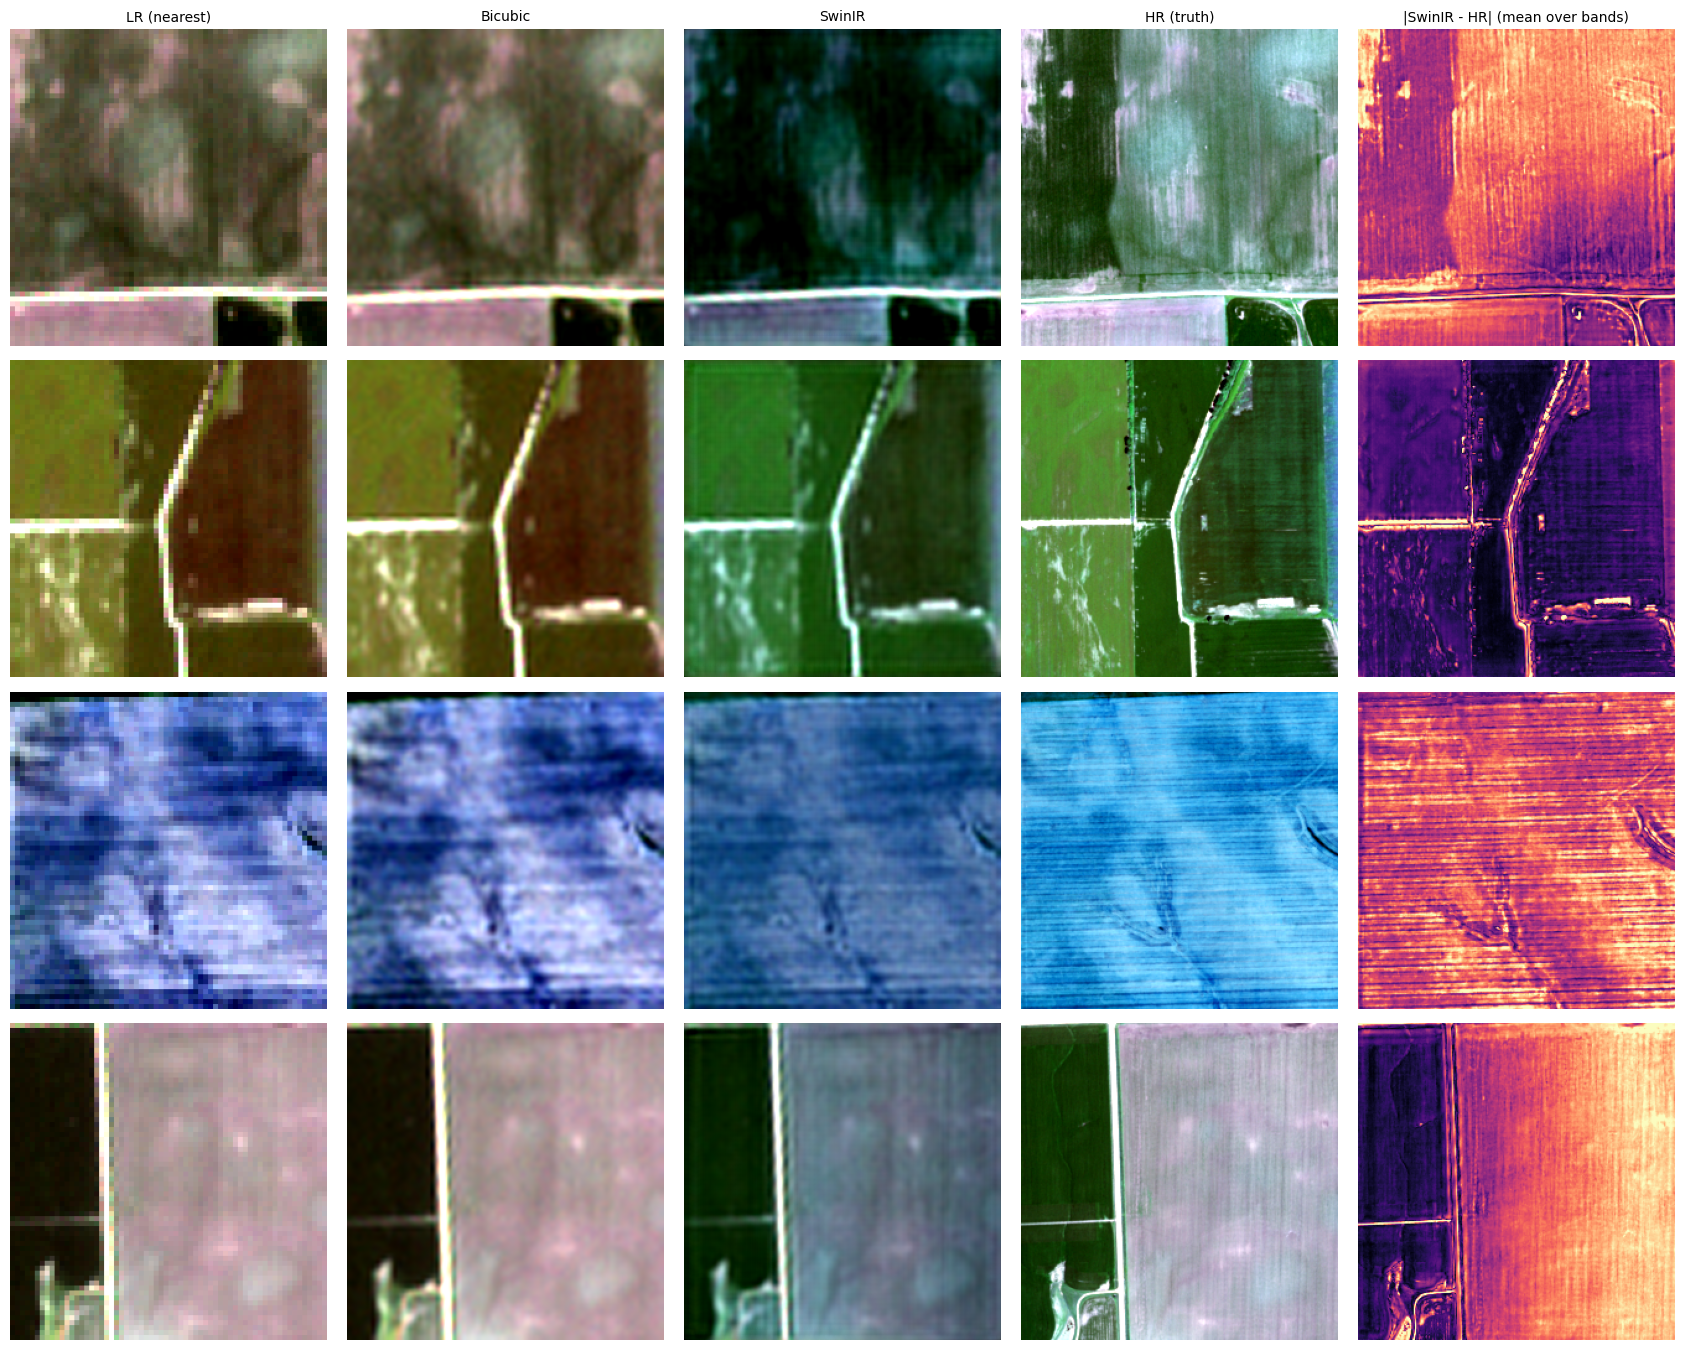

Images shown with bands [2, 1, 0] as RGB. If colours look wrong, set DISPLAY_BANDS in cell 1.


In [ ]:
ck = torch.load(BEST, map_location=DEVICE, weights_only=False)
model.load_state_dict(ck['model']); model.eval()
print(f'Loaded best checkpoint from epoch {ck["epoch"] + 1}')

def predict_mc(x, n=5):
    enable_mc_dropout(model)
    out = torch.stack([predict_swin(x).float() for _ in range(n)]).mean(0)
    model.eval()
    return out

rows = {'Bicubic': evaluate(bicubic_fn, test_loader)}
if 'srcnn' in globals():
    rows['SRCNN'] = evaluate(srcnn_fn, test_loader)
rows['SwinIR'] = evaluate(predict_swin, test_loader)
rows['SwinIR MC-mean(5)'] = evaluate(predict_mc, test_loader)

summary = pd.DataFrame({k: {'PSNR': v['psnr'], 'SSIM': v['ssim'], 'SAM(deg)': v['sam']} for k, v in rows.items()}).T
print('\nTEST RESULTS (PSNR/SSIM higher = better, SAM lower = better)')
print(summary.round(4))
band_tab = pd.DataFrame({k: v['band_psnr'] for k, v in rows.items()}, index=BAND_LABELS).round(3)
print('\nPer-band PSNR (dB) — check the NIR band is not worse than bicubic:')
print(band_tab)
summary.to_csv(os.path.join(CKPT_DIR, 'test_results.csv'))
band_tab.to_csv(os.path.join(CKPT_DIR, 'test_results_per_band.csv'))
TEST_METRICS = {k: dict(psnr=v['psnr'], ssim=v['ssim'], sam=v['sam']) for k, v in rows.items()}

# ---- side-by-side images ----
if DISPLAY_BANDS is not None:
    dbands = DISPLAY_BANDS
elif NUM_CH >= 3:
    dbands = [2, 1, 0]          # guess: bands are ordered B,G,R,(NIR). Set DISPLAY_BANDS if your order differs.
else:
    dbands = [0, 0, 0]

def to_rgb(img, ref):
    x = img[dbands].transpose(1, 2, 0)
    r = ref[dbands].transpose(1, 2, 0)
    lo_, hi_ = np.percentile(r, 2), np.percentile(r, 98)
    return np.clip((x - lo_) / (hi_ - lo_ + 1e-8), 0, 1)

idxs = np.random.RandomState(SEED).choice(len(test_ds), 4, replace=False)
fig, axes = plt.subplots(len(idxs), 5, figsize=(17, 3.4 * len(idxs)))
titles = ['LR (nearest)', 'Bicubic', 'SwinIR', 'HR (truth)', '|SwinIR - HR| (mean over bands)']
for r, i in enumerate(idxs):
    lr, hr = test_ds[i]
    with torch.no_grad():
        lr_g = lr[None].to(DEVICE)
        bic = bicubic_fn(lr_g)[0].cpu().numpy()
        sw = predict_swin(lr_g)[0].float().cpu().numpy()
    hr_n = hr.numpy()
    near = np.repeat(np.repeat(lr.numpy(), SCALE, 1), SCALE, 2)
    err = np.abs(sw - hr_n).mean(0)
    for c, im in enumerate([near, bic, sw, hr_n]):
        axes[r, c].imshow(to_rgb(im, im if c < 2 else hr_n))
    axes[r, 4].imshow(err, cmap='magma', vmin=0, vmax=np.percentile(err, 99))
    for c in range(5):
        axes[r, c].axis('off')
        if r == 0: axes[r, c].set_title(titles[c], fontsize=10)
plt.tight_layout(); plt.savefig(os.path.join(CKPT_DIR, 'test_side_by_side.png'), dpi=110); plt.show()
print('Images shown with bands', dbands, 'as RGB. If colours look wrong, set DISPLAY_BANDS in cell 1.')

## 10. Inference: tiled + feathered stitching + MC Dropout (5 passes)
Works on any LR image size. Tiles overlap and are blended with a smooth feather window, so no seams.
Returns the MC mean (final SR image), per-band std, and an uncertainty heatmap (mean std over bands).

Output shape: (4, 256, 256) (from LR (4, 64, 64))
Seam check (tiled vs whole image, deterministic), max diff in normalized units: 0.0170 (small = good)
Correlation between uncertainty and absolute error: 0.011 (positive = uncertainty is informative)
Output value range: 68.5 .. 164.9 (should be inside ~0-255)
Mean uncertainty: 0.00227 | max: 0.00819


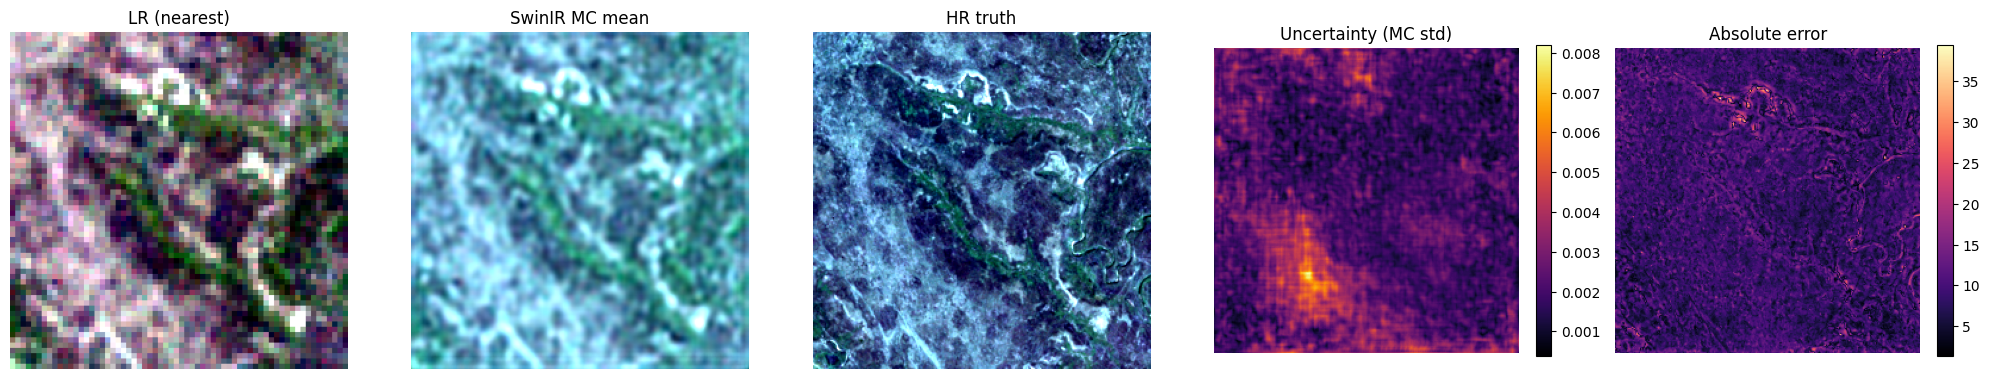

In [ ]:
INFER_SRC = r"""
import numpy as np

def as_chw(arr, num_ch):
    arr = np.asarray(arr)
    if arr.ndim == 2:
        arr = arr[None]
    if arr.shape[0] == num_ch:
        return arr
    if arr.shape[-1] == num_ch:
        return arr.transpose(2, 0, 1)
    raise ValueError(f'Cannot find {num_ch} channels in array of shape {arr.shape}')

def load_model(path, device=None):
    device = torch.device(device or ('cuda' if torch.cuda.is_available() else 'cpu'))
    ck = torch.load(path, map_location='cpu', weights_only=False)
    model = SwinIR(**ck['cfg'])
    model.load_state_dict(ck['model'])
    model.to(device).eval()
    return model, ck['norm']

def _tile_starts(n, tile, stride):
    if n <= tile:
        return [0]
    s = list(range(0, n - tile, stride))
    s.append(n - tile)
    return sorted(set(s))

def _feather(n, ramp, floor=0.05):
    r = min(ramp, n // 2)
    v = torch.ones(n)
    if r > 0:
        t = (torch.arange(r).float() + 0.5) / r
        t = floor + (1 - floor) * 0.5 * (1 - torch.cos(math.pi * t))
        v[:r] = t
        v[-r:] = torch.flip(t, [0])
    return v

@torch.no_grad()
def super_resolve(model, norm, lr, mc_passes=5, tile=64, overlap=16, batch_tiles=4, fp16=True):
    # lr: numpy array (C,H,W) in the ORIGINAL physical units. Returns dict of numpy arrays.
    # mc_passes=0 -> deterministic (dropout off). mc_passes>=2 -> Monte Carlo Dropout.
    device = next(model.parameters()).device
    s = model.scale
    assert tile % model.ws == 0, 'tile must be a multiple of the window size (8)'
    assert 0 <= overlap < tile
    lo = torch.tensor(norm['lr_lo'], dtype=torch.float32).view(1, -1, 1, 1)   # INPUT uses LR stats
    hi = torch.tensor(norm['lr_hi'], dtype=torch.float32).view(1, -1, 1, 1)
    x = torch.from_numpy(np.nan_to_num(np.asarray(lr, dtype=np.float32))).unsqueeze(0)
    x = (x - lo) / (hi - lo)
    _, C, H, W = x.shape
    ph, pw = max(0, tile - H), max(0, tile - W)
    if ph or pw:
        x = F.pad(x, (0, pw, 0, ph), mode='replicate')
    Hp, Wp = x.shape[2:]
    coords = [(y, xx) for y in _tile_starts(Hp, tile, tile - overlap) for xx in _tile_starts(Wp, tile, tile - overlap)]
    win = (_feather(tile * s, overlap * s)[:, None] * _feather(tile * s, overlap * s)[None, :])
    acc_m = torch.zeros(C, Hp * s, Wp * s)
    acc_s = torch.zeros(C, Hp * s, Wp * s)
    acc_w = torch.zeros(Hp * s, Wp * s)
    if mc_passes and mc_passes > 0:
        enable_mc_dropout(model)
    else:
        model.eval()
    use_amp = fp16 and device.type == 'cuda'
    for i in range(0, len(coords), batch_tiles):
        cb = coords[i:i + batch_tiles]
        xb = torch.cat([x[:, :, y:y + tile, xx:xx + tile] for y, xx in cb]).to(device)
        n_pass = mc_passes if (mc_passes and mc_passes > 0) else 1
        preds = []
        for _ in range(n_pass):
            with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=use_amp):
                preds.append(model(xb).float())
        P = torch.stack(preds)
        mean = P.mean(0)
        std = P.std(0, correction=1) if n_pass > 1 else torch.zeros_like(mean)
        mean, std = mean.cpu(), std.cpu()
        for j, (y, xx) in enumerate(cb):
            ys, xs = slice(y * s, (y + tile) * s), slice(xx * s, (xx + tile) * s)
            acc_m[:, ys, xs] += mean[j] * win
            acc_s[:, ys, xs] += std[j] * win
            acc_w[ys, xs] += win
    model.eval()
    mean = (acc_m / acc_w)[:, :H * s, :W * s]
    std = (acc_s / acc_w)[:, :H * s, :W * s]
    hlo = torch.tensor(norm['hr_lo'], dtype=torch.float32).view(-1, 1, 1)     # OUTPUT uses HR stats
    hhi = torch.tensor(norm['hr_hi'], dtype=torch.float32).view(-1, 1, 1)
    rng = hhi - hlo
    out = mean * rng + hlo
    vmin = torch.tensor(norm['vmin'], dtype=torch.float32).view(-1, 1, 1)
    vmax = torch.tensor(norm['vmax'], dtype=torch.float32).view(-1, 1, 1)
    out = torch.max(torch.min(out, vmax), vmin)
    return dict(mean=out.numpy().astype(np.float32),
                std=(std * rng).numpy().astype(np.float32),
                uncertainty=std.mean(0).numpy().astype(np.float32))
"""
exec(INFER_SRC, globals())

# ---- demo on one test patch (tile=32 on purpose, so stitching is really exercised) ----
model.load_state_dict(torch.load(BEST, map_location=DEVICE, weights_only=False)['model'])
row = test_df.iloc[int(np.random.RandomState(SEED).randint(len(test_df)))]
lr_raw = to_chw(np.load(row['lr_path']), False).astype(np.float32)
hr_raw = to_chw(np.load(row['hr_path']), True).astype(np.float32)

res = super_resolve(model, NORM, lr_raw, mc_passes=5, tile=32, overlap=8)
det_t = super_resolve(model, NORM, lr_raw, mc_passes=0, tile=32, overlap=8)['mean']
det_f = super_resolve(model, NORM, lr_raw, mc_passes=0, tile=LR_SIZE, overlap=0)['mean']
rng_np = (HI_HR - LO_HR).reshape(-1, 1, 1)
seam = float((np.abs(det_t - det_f) / rng_np).max())
print(f'Output shape: {res["mean"].shape} (from LR {lr_raw.shape})')
print(f'Seam check (tiled vs whole image, deterministic), max diff in normalized units: {seam:.4f} (small = good)')

err = np.abs(res['mean'] - hr_raw).mean(0)
corr = np.corrcoef(res['uncertainty'].ravel(), err.ravel())[0, 1]
print(f'Correlation between uncertainty and absolute error: {corr:.3f} (positive = uncertainty is informative)')
print(f'Output value range: {res["mean"].min():.1f} .. {res["mean"].max():.1f} (should be inside ~0-255)')
print(f'Mean uncertainty: {res["uncertainty"].mean():.5f} | max: {res["uncertainty"].max():.5f}')

hr_n = (hr_raw - LO.reshape(-1, 1, 1)) / rng_np
sr_n = (res['mean'] - LO.reshape(-1, 1, 1)) / rng_np
near = np.repeat(np.repeat((lr_raw - LO_LR.reshape(-1, 1, 1)) / (HI_LR - LO_LR).reshape(-1, 1, 1), SCALE, 1), SCALE, 2)
fig, ax = plt.subplots(1, 5, figsize=(20, 4))
for a, im, t in zip(ax[:3], [near, sr_n, hr_n], ['LR (nearest)', 'SwinIR MC mean', 'HR truth']):
    a.imshow(to_rgb(im, im if t.startswith('LR') else hr_n)); a.set_title(t)
h1 = ax[3].imshow(res['uncertainty'], cmap='inferno'); ax[3].set_title('Uncertainty (MC std)'); plt.colorbar(h1, ax=ax[3], fraction=0.046)
h2 = ax[4].imshow(err, cmap='magma'); ax[4].set_title('Absolute error'); plt.colorbar(h2, ax=ax[4], fraction=0.046)
for a in ax: a.axis('off')
plt.tight_layout(); plt.savefig(os.path.join(CKPT_DIR, 'inference_demo.png'), dpi=110); plt.show()

## 11. Export the .pth and a standalone inference script
Saves one final .pth (weights + model config + normalization + metadata), a standalone `sr_inference.py`
(uses the same model/inference code as above), a README for teammates, and runs a self-test of the script.

In [ ]:
FINAL_PTH = os.path.join(CKPT_DIR, 'ntro26142_swinir_x4_final.pth')
SCRIPT_PATH = os.path.join(CKPT_DIR, 'sr_inference.py')
README_PATH = os.path.join(CKPT_DIR, 'README_handover.txt')

best_ck = torch.load(BEST, map_location='cpu', weights_only=False)
final = dict(model={k: v.cpu() for k, v in best_ck['model'].items()}, cfg=MODEL_CFG, norm=NORM,
             scale=SCALE, mc_passes=5, best_epoch=int(best_ck['epoch']) + 1,
             test_metrics=TEST_METRICS, note='NTRO 26142 Sentinel-2 4x SwinIR with MC Dropout')
torch.save(final, FINAL_PTH)
print('Saved:', FINAL_PTH, f'({os.path.getsize(FINAL_PTH) / 1e6:.1f} MB)')

MAIN_SRC = r"""

if __name__ == '__main__':
    import argparse
    ap = argparse.ArgumentParser(description='Sentinel-2 4x super-resolution with MC Dropout uncertainty')
    ap.add_argument('--input', required=True, help='LR .npy file, shape (C,H,W) or (H,W,C), original units')
    ap.add_argument('--model', required=True, help='path to the final .pth')
    ap.add_argument('--out', default='sr_out', help='output prefix')
    ap.add_argument('--passes', type=int, default=5, help='MC Dropout passes (0 = deterministic)')
    ap.add_argument('--tile', type=int, default=64)
    ap.add_argument('--overlap', type=int, default=16)
    ap.add_argument('--device', default=None)
    a = ap.parse_args()
    model, norm = load_model(a.model, a.device)
    lr = as_chw(np.load(a.input), norm['num_ch']).astype(np.float32)
    res = super_resolve(model, norm, lr, mc_passes=a.passes, tile=a.tile, overlap=a.overlap)
    np.save(a.out + '_sr.npy', res['mean'])
    np.save(a.out + '_std.npy', res['std'])
    np.save(a.out + '_uncertainty.npy', res['uncertainty'])
    print('SR image      :', a.out + '_sr.npy', res['mean'].shape, '(C,H*4,W*4, float32, HR / NAIP-style 0-255 units)')
    print('Per-band std  :', a.out + '_std.npy', res['std'].shape)
    print('Uncertainty   :', a.out + '_uncertainty.npy', res['uncertainty'].shape, '(mean std over bands, normalized)')
    try:
        import matplotlib
        matplotlib.use('Agg')
        import matplotlib.pyplot as plt
        plt.imsave(a.out + '_uncertainty.png', res['uncertainty'], cmap='inferno')
        print('Heatmap image :', a.out + '_uncertainty.png')
    except Exception as e:
        print('Heatmap png skipped:', e)
"""
HEADER = '# Standalone inference for NTRO 26142 (Sentinel-2 4x SR + MC Dropout).\n# Needs only: torch, numpy (matplotlib optional for the PNG).\n# Usage: python sr_inference.py --input lr.npy --model ntro26142_swinir_x4_final.pth --out result --passes 5\nimport numpy as np\n'
with open(SCRIPT_PATH, 'w') as f:
    f.write(HEADER + MODEL_SRC + INFER_SRC + MAIN_SRC)
print('Saved:', SCRIPT_PATH)

readme = f"""NTRO 26142 — Sentinel-2 4x super-resolution (10 m -> 2.5 m), SwinIR + MC Dropout
Files: ntro26142_swinir_x4_final.pth, sr_inference.py (needs torch + numpy)

Data format the model expects (detected from the training data)
- channels: {NUM_CH}   layout in training files: {LAYOUT}   (the script accepts CHW or HWC)
- band labels: {BAND_LABELS}   (order = same order as the training .npy files)
- LR patch: {LR_SIZE}x{LR_SIZE}, output is {SCALE}x larger. Any LR size works (tiled).
- INPUT: Sentinel-2 LR in its original units. LR normalization used in training (per band):
  lo = {[round(float(x), 1) for x in LO_LR]}
  hi = {[round(float(x), 1) for x in HI_LR]}
- HR band reorder applied during training: {HR_ORDER}
- OUTPUT: float32 in NAIP-style HR units (about 0-255). HR normalization used in training (per band):
  lo = {[round(float(x), 1) for x in LO_HR]}
  hi = {[round(float(x), 1) for x in HI_HR]}
  Output is clipped to the training HR data range.

Command line
  python sr_inference.py --input lr.npy --model ntro26142_swinir_x4_final.pth --out result --passes 5
  -> result_sr.npy (C,H*4,W*4), result_std.npy (per-band std), result_uncertainty.npy (H*4,W*4), result_uncertainty.png

Python
  from sr_inference import load_model, super_resolve, as_chw
  model, norm = load_model('ntro26142_swinir_x4_final.pth')
  out = super_resolve(model, norm, lr_chw, mc_passes=5)   # out['mean'], out['std'], out['uncertainty']

Monte Carlo Dropout: dropout stays ON at inference, 5 forward passes; mean = final image,
std = uncertainty (higher = less reliable). Use --passes 0 for a deterministic result.
Test metrics (zip 007, unseen ROIs): {json.dumps({k: {m: round(x, 4) for m, x in v.items()} for k, v in TEST_METRICS.items()})}
"""
with open(README_PATH, 'w') as f:
    f.write(readme)
print('Saved:', README_PATH)

# ---- self-test: run the standalone script on one real test patch ----
sample_in = '/content/selftest_lr.npy'
np.save(sample_in, np.load(test_df.iloc[0]['lr_path']))
proc = subprocess.run([sys.executable, SCRIPT_PATH, '--input', sample_in, '--model', FINAL_PTH,
                       '--out', '/content/selftest', '--passes', '5'], capture_output=True, text=True)
print('\n--- standalone script self-test ---')
print(proc.stdout[-1500:] if proc.returncode == 0 else proc.stderr[-2500:])
if proc.returncode == 0:
    o = np.load('/content/selftest_sr.npy')
    assert o.shape[0] == NUM_CH and o.shape[1] == LR_SIZE * 4, o.shape
    print('Self-test PASSED. Output shape', o.shape, '| everything is in Drive folder:', CKPT_DIR)
    print(f'Output value range: {o.min():.1f} .. {o.max():.1f} (should be inside ~0-255)')
else:
    print('Self-test FAILED — read the error above.')
# Optional direct download to your laptop:
# from google.colab import files; files.download(FINAL_PTH); files.download(SCRIPT_PATH)

Saved: /content/drive/MyDrive/ntro_sr_outputs/ntro26142_swinir_x4_final.pth (8.6 MB)
Saved: /content/drive/MyDrive/ntro_sr_outputs/sr_inference.py
Saved: /content/drive/MyDrive/ntro_sr_outputs/README_handover.txt

--- standalone script self-test ---
SR image      : /content/selftest_sr.npy (4, 256, 256) (C,H*4,W*4, float32, HR / NAIP-style 0-255 units)
Per-band std  : /content/selftest_std.npy (4, 256, 256)
Uncertainty   : /content/selftest_uncertainty.npy (256, 256) (mean std over bands, normalized)
Heatmap image : /content/selftest_uncertainty.png

Self-test PASSED. Output shape (4, 256, 256) | everything is in Drive folder: /content/drive/MyDrive/ntro_sr_outputs
Output value range: 82.8 .. 179.2 (should be inside ~0-255)


In [ ]:
import numpy as np, os
from PIL import Image
SEED = 42 # Defined in an earlier cell, added here for 독립적 실행
os.makedirs('/content/samples', exist_ok=True)
idxs = np.random.RandomState(SEED).choice(len(test_ds), 4, replace=False)
for k, i in enumerate(idxs, 1):
    r = test_df.iloc[int(i)]
    lr = np.load(r['lr_path']); hr = np.load(r['hr_path'])   # both HxWx4
    np.save(f'/content/samples/sample_{k:02d}.npy', lr)
    rgb = hr[..., [2, 1, 0]].astype(np.float32)
    lo, hi = np.percentile(rgb, [2, 98])
    rgb = np.clip((rgb - lo) / (hi - lo + 1e-8), 0, 1)
    Image.fromarray((rgb * 255).astype(np.uint8)).save(f'/content/samples/sample_{k:02d}_hr.png')
!cd /content && zip -r samples.zip samples && cp samples.zip /content/drive/MyDrive/ntro_sr_outputs/

  adding: samples/ (stored 0%)
  adding: samples/sample_01_hr.png (deflated 0%)
  adding: samples/sample_03.npy (deflated 59%)
  adding: samples/sample_04_hr.png (deflated 0%)
  adding: samples/sample_03_hr.png (deflated 0%)
  adding: samples/sample_04.npy (deflated 57%)
  adding: samples/sample_01.npy (deflated 56%)
  adding: samples/sample_02.npy (deflated 55%)
  adding: samples/sample_02_hr.png (deflated 0%)
